How many simulated vehicles would you like to test?  6
How many simulations would you like to run?  1000000
How many miles does your car have?  1500
How many miles does your car have?  15000
How many miles does your car have?  150000
How many miles does your car have?  250000
How many miles does your car have?  350000
How many miles does your car have?  450000



    miles  mean_life  median_life  mech_fail_pct  <2.5k
0    1500   200991.0     195317.1           79.9    0.2
1   15000   190173.8     183511.6           81.0    0.3
2  150000   107466.1      93752.2           89.3    1.3
3  250000    73096.4      58996.1           92.7    2.5
4  350000    52255.9      40003.7           94.8    3.9
5  450000    39096.1      28956.2           96.1    5.6


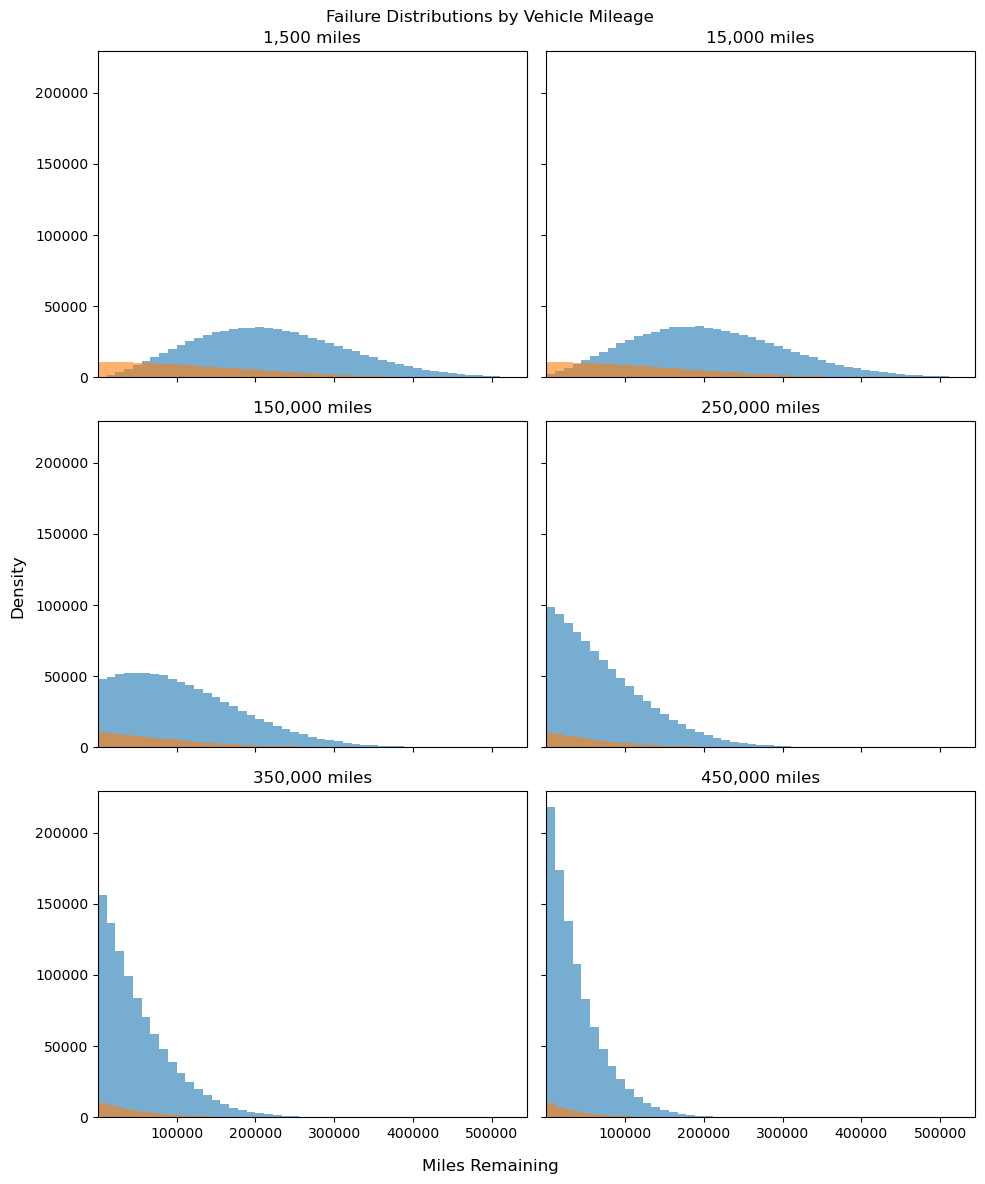

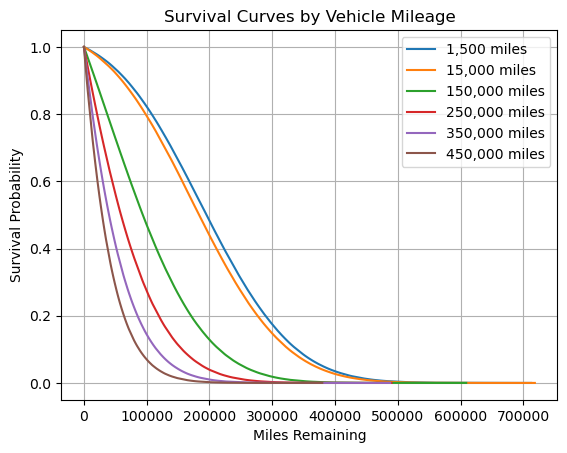

In [16]:
# We are going to start with a simple model.
import numpy as np 
import pandas as pd 
import scipy.stats as ss 
import matplotlib.pyplot as plt

# Here are the inputs.

k = input("How many simulated vehicles would you like to test? ") 
k = int(k) 
n = input("How many simulations of each car would you like to run? ") 
n = int(n) 

# The initial conditions. Currently, they are set to be a mean of 200,000 miles until a devastating (totaling) wreck occurs, 
# and a mean of 260,000 miles until the car breaks down.
# Miles per month is just for the data frame and will calculate the expected probability the car will break down in the next month.

wreck_mean = 200000 
exp_miles = 260000 
miles_per_month = 2500 

# We iterate through the inputs...

miles_list = [] 
for _ in range(k): 
    miles = input("How many miles does your car have? ") 
    miles = int(miles) 
    miles_list.append(miles)

def car_sim(mi): 
    miles_prob = ss.weibull_min.cdf(mi, c=2.5, scale=exp_miles) 
    randoms = np.random.uniform(miles_prob, 1, size=n) 
    rand_conv = ss.weibull_min.ppf(randoms, c=2.5, scale=exp_miles) 
    miles_left = rand_conv - mi 
    fatal_wreck = np.random.exponential(wreck_mean, size = n) 
    life_left = np.minimum(miles_left, fatal_wreck) 
    death_type = (fatal_wreck > miles_left).astype(int) 
    prob = death_type.mean()*100 
    next_month = (life_left < miles_per_month).mean() * 100 
    return ( life_left, death_type, mi, n, life_left.mean(), np.median(life_left), prob, next_month )

# ... and build a dataframe of the information gathered in the Monte Carlo simulation.

list_ll = [] 
list_dt = [] 
list_n = [] 
list_v = [] 
list_q = [] 
list_p = [] 
list_x = []

for mi in miles_list: 
    ll,dt,miles,m,v,q,p,x = car_sim(mi) 
    list_ll.append(ll) 
    list_dt.append(dt) 
    list_n.append(miles) 
    list_v.append(v) 
    list_q.append(q) 
    list_p.append(p) 
    list_x.append(x)

nmv = pd.DataFrame({ 
    "miles": list_n, 
    "mean_life": list_v, 
    "median_life": list_q, 
    "mech_fail_pct": list_p, 
    f"<{miles_per_month/1000:.1f}k": list_x 
})

print() 
print(nmv.round(1))

# Now, we set up histograms for each car, with global scales on the X and Y axes.

global_min = min(ll.min() for ll in list_ll) 
global_max = max(np.percentile(ll, 99.9) for ll in list_ll) 
bins = np.linspace(global_min, global_max, 50)

rows = int(np.ceil(len(list_ll) / 2)) 
cols = 2

fig, axes = plt.subplots(rows, cols, figsize=(10, 4 * rows), sharex=True, sharey=True) 
axes = axes.flatten()

for idx, (ll, dt, mi) in enumerate(zip(list_ll, list_dt, list_n)): 
    ax = axes[idx]

    ax.hist(ll[dt == 1], bins=bins, alpha=0.6, label="Mechanical")
    ax.hist(ll[dt == 0], bins=bins, alpha=0.6, label="Accident")

    ax.set_title(f"{mi:,} miles")
    ax.set_xlim(global_min, global_max)

if idx == 0:
    ax.legend()
for j in range(idx + 1, len(axes)): 
    fig.delaxes(axes[j])

fig.supxlabel("Miles Remaining") 
fig.supylabel("Density") 
fig.suptitle("Failure Distributions by Vehicle Mileage")

plt.tight_layout() 
plt.show()

plt.figure()

#Finally, we make a survival chart for all the cars.

for ll, mi in zip(list_ll, list_n): 
    sorted_life = np.sort(ll) 
    survival = 1 - np.arange(1, len(sorted_life)+1) / len(sorted_life)

    plt.plot(sorted_life, survival, label=f"{mi:,} miles")
    
plt.xlabel("Miles Remaining") 
plt.ylabel("Survival Probability") 
plt.title("Survival Curves by Vehicle Mileage") 
plt.legend() 
plt.grid(True)

plt.show()